In [1]:
!pip install -q augly
!pip install -q librosa
!pip install torchinfo
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import pickle
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import torch.optim as optim
import os
from google.colab import drive
if not os.path.exists('/content/drive'):
   drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 21.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# Run this once before initializing the dataset
!cp "/content/drive/MyDrive/data/Drone_Train.h5" "/content/Drone_Train.h5"
!cp "/content/drive/MyDrive/data/Drone_Validation.h5" "/content/Drone_Validation.h5"
!cp "/content/drive/MyDrive/data/Drone_Test.h5" "/content/Drone_Test.h5"

In [3]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 241 (delta 38), reused 0 (delta 0), pack-reused 149 (from 1)
Receiving objects: 100% (241/241), 3.07 MiB | 7.70 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/Final-year-project-2026


In [4]:

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image

import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image

class DroneFusionDatasetH5(Dataset):
    def __init__(
        self,
        h5_path,
        transform=None,  # Dict containing your get_audio_transform, get_img_transform, etc.
        audio_feature_type='logmel',
        modalities=['audio', 'video', 'rf'],
        is_training=True,
        n_mfcc=40,
        n_fft=2048,
        hop_length=512,
        n_mels=64,
        segment_length=0.25
    ):
        self.h5_path = h5_path
        self.audio_feature_type = audio_feature_type.lower()
        self.modalities = [m.lower() for m in modalities]
        self.is_training = is_training

        self.transform = transform or {}
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.segment_length = segment_length

        if not os.path.exists(self.h5_path):
            raise FileNotFoundError(f"HDF5 file not found at: {self.h5_path}")

        # Extract metadata
        with h5py.File(self.h5_path, 'r') as f:
            self.length = len(f['labels'])
            # Native SR from the H5 attributes (set during packing)
            self.native_sr = int(f.attrs.get('sr', 44100))

    def _extract_logmel(self, y, sr):
        # Exact logic from your original loader
        target_frames = int(np.ceil(self.segment_length / (138 / sr)))

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=138,
            n_mels=self.n_mels, power=2.0
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Z-score normalization
        log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

        if log_mel.shape[1] < target_frames:
            pad_width = target_frames - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
        else:
            log_mel = log_mel[:, :target_frames]

        return torch.from_numpy(log_mel).unsqueeze(0).float()

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open inside getitem for DataLoader worker safety
        with h5py.File(self.h5_path, 'r') as f:
            # 1. Label
            label = torch.tensor(f['labels'][idx], dtype=torch.long)

            # 2. Audio Processing
            audio_tensor = torch.empty(0)
            if 'audio' in self.modalities:
                waveform = f['audio'][idx].astype(np.float32)
                sr = self.native_sr

                # Apply your custom get_audio_transform (augly/logmel_augment)
                if 'audio' in self.transform:
                    waveform, sr = self.transform['audio'](waveform, sr)

                if self.audio_feature_type == 'logmel':
                  # Resample only for Log-Mel
                  waveform = librosa.resample(waveform, orig_sr=self.native_sr, target_sr=22050)
                  sr = 22050

                  max_val = np.max(np.abs(waveform))
                  if max_val > 0: waveform /= max_val
                  audio_tensor = self._extract_logmel(waveform, sr)
                else:
                    # MFCC "Diff Sampling" [::3]
                    waveform_sub = np.asfortranarray(waveform[::3])
                    mfcc = librosa.feature.mfcc(
                        y=waveform_sub, sr=sr, n_mfcc=self.n_mfcc,
                        n_fft=self.n_fft, hop_length=self.hop_length
                    )
                    pad_width = max(0, self.n_mfcc - mfcc.shape[1])
                    if pad_width > 0:
                        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
                    audio_tensor = torch.from_numpy(mfcc).float().unsqueeze(0)

            # 3. Video Processing (Using your get_img_transform)
            video_tensor = torch.empty(0)
            if 'video' in self.modalities:
                video_data = f['video'][idx]
                v_trans = self.transform.get('video')
                if v_trans:
                    # Logic: uint8 -> PIL -> your Compose (ToTensor + Augments + Normalize)
                    v_frames = [v_trans(Image.fromarray(video_data[i])) for i in range(len(video_data))]
                    video_tensor = torch.stack(v_frames)

            # 4. RF Processing (Using your get_rf_transform)
            rf_tensor = torch.empty(0)
            if 'rf' in self.modalities:
                rf_data = f['rf'][idx]
                rf_trans = self.transform.get('rf')
                if rf_trans:
                    # Logic: uint8 -> PIL -> your Compose (Resize + ToTensor + rf_aug + Normalize)
                    rf_frames = [rf_trans(Image.fromarray(rf_data[i])) for i in range(len(rf_data))]
                    rf_tensor = torch.stack(rf_frames)

        return audio_tensor, video_tensor, rf_tensor, label


In [12]:
from torch.utils.data import DataLoader
class Args:
    dataset_dir = '/content'
    batch_size = 32
    feature_type = 'logmel'  # Changed to 'logmel' to match model's expected input

    # Dynamic parameter selection based on original loader requirements
    n_mfcc = 40
    n_mels = 64 if feature_type == 'logmel' else 40
    num_workers =2
    pin_memory = True
    modalities = ['audio', 'video', 'rf']
    crop_size = 112

args = Args()

# --- 3. Setup Transforms ---
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

train_transform = {
    'audio': get_audio_transform(args, is_training=True, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=True, augment=True),
    'rf': get_rf_transform(args, is_training=True, augment=True)
}

val_transform = {
    'audio': get_audio_transform(args, is_training=False, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=False, augment=False),
    'rf': get_rf_transform(args, is_training=False, augment=False)
}

# --- 4. Initialize Datasets & Loaders ---

train_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Train.h5'),
    transform=train_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=True
)

val_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Validation.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


test_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Test.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)


loaders = {
    'train': DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'val': DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory),
    'test': DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory)
}

# --- 5. Final Printing and Verification ---
print(f"--- Dataset Summary ---")
print(f"Train Samples: {len(train_dataset)} | Batches: {len(loaders['train'])}")
print(f"Val Samples:   {len(val_dataset)} | Batches: {len(loaders['val'])}")
print(f"Val Samples:   {len(test_dataset)} | Batches: {len(loaders['test'])}\n")
print(f"--- Input Shape Verification ---")

audio_b, video_b, rf_b, label_b = next(iter(loaders['train']))
print(f"Audio Shape: {audio_b.shape}")
print(f"Video Shape: {video_b.shape}")
print(f"RF Shape:    {rf_b.shape}")
print(f"Label Shape: {label_b.shape}")

--- Dataset Summary ---
Train Samples: 8480 | Batches: 265
Val Samples:   1280 | Batches: 40
Val Samples:   1320 | Batches: 42

--- Input Shape Verification ---
Audio Shape: torch.Size([32, 1, 64, 40])
Video Shape: torch.Size([32, 7, 3, 112, 112])
RF Shape:    torch.Size([32, 1, 3, 112, 112])
Label Shape: torch.Size([32])


In [13]:
# all_models.py must be in the cloned repo folder
from models.all_models import (
    LogMelCNN_64,
    AudioVGG19,
    Visual_MobileNet,
    Modality3DCNN,
    RF_ResNet18,
)



In [7]:
import torch.nn as nn
class LateFusionModel(nn.Module):
    """
    Late fusion for any combination of Audio / Video / RF.
    Mirrors the paper's LateFusion3Modal:
      - Each backbone output -> normalised probability [B, 1]
      - Concatenated         -> [B, num_active]
      - Linear(num_active,1) + Sigmoid -> [B]
    """

    def __init__(self, model_audio=None, model_visual=None, model_rf=None,
                 num_classes=2):
        super(LateFusionModel, self).__init__()

        self.audio  = model_audio
        self.visual = model_visual
        self.rf     = model_rf

        num_active = sum([model_audio  is not None,
                          model_visual is not None,
                          model_rf     is not None])
        if num_active == 0:
            raise ValueError('At least one backbone must be provided.')

        # paper: nn.Linear(num_classes+1, num_classes-1) == Linear(3,1) for tri-modal
        self.final_pred = nn.Sequential(
            nn.Linear(num_active, num_classes - 1),
            nn.Sigmoid()
        )

    @staticmethod
    def _get_prob(model_out):
        """Normalise backbone output to [B, 1] probability."""
        if isinstance(model_out, (list, tuple)):
            model_out = model_out[-1]                        # paper: out[-1]
        model_out = model_out.view(model_out.size(0), 1)    # -> [B, 1]
        if model_out.min() < 0.0 or model_out.max() > 1.0:
            model_out = torch.sigmoid(model_out)             # fallback for logits
        return model_out                                     # [B, 1]

    def forward(self, audio=None, video=None, rf=None):
        probs = []

        if self.audio is not None:
            probs.append(self._get_prob(self.audio(audio)))

        if self.visual is not None:
            probs.append(self._get_prob(self.visual(video)))

        if self.rf is not None:
            if rf.ndim == 5:
                rf = rf[:, 0]                                # [B,T,C,H,W]->[B,C,H,W]
            probs.append(self._get_prob(self.rf(rf)))

        combined = torch.cat(probs, dim=-1)                  # [B, num_active]
        pred = self.final_pred(combined).squeeze()           # [B]
        return pred


In [8]:
PAIRED_COLORS = ['#1f78b4', '#a6cee3', '#b2df8a', '#33a02c']
CLASS_NAMES   = ['No-Drone', 'Drone']


def plot_training_history(history, title_prefix='Late Fusion'):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    plt.plot(epochs, history['val_loss'],   'o-', label='Val Loss')
    plt.title(f'{title_prefix} — Loss vs Epochs')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    plt.plot(epochs, history['val_acc'],   'o-', label='Val Acc')
    plt.title(f'{title_prefix} — Accuracy vs Epochs')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()


def plot_per_class_metrics_group(y_true, y_pred, dataset_name='Dataset'):
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall    = recall_score(y_true,    y_pred, average=None, zero_division=0)
    f1        = f1_score(y_true,        y_pred, average=None, zero_division=0)
    accuracy  = [accuracy_score(y_true, y_pred)] * len(CLASS_NAMES)
    x, width  = np.arange(len(CLASS_NAMES)), 0.2
    plt.figure(figsize=(8, 5))
    plt.bar(x - 1.5*width, precision, width, label='Precision', color=PAIRED_COLORS[0])
    plt.bar(x - 0.5*width, recall,    width, label='Recall',    color=PAIRED_COLORS[1])
    plt.bar(x + 0.5*width, f1,        width, label='F1-score',  color=PAIRED_COLORS[2])
    plt.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color=PAIRED_COLORS[3])
    plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1); plt.ylabel('Score')
    plt.title(f'Per-Class Metrics ({dataset_name})')
    plt.legend(); plt.tight_layout(); plt.show()


def print_classification_report(y_true, y_pred, dataset_name='Dataset'):
    print(f'\n===== {dataset_name} Classification Report =====')
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES, digits=4))


In [9]:
def train_fusion(model, dataloaders, device, optimizer, criterion, num_epochs=10):
    history    = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    best_wts   = copy.deepcopy(model.state_dict())
    best_acc   = 0.0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f'  Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, all_preds, all_labels = 0.0, [], []

            for audio, video, rf, labels in tqdm(dataloaders[phase],
                                                  desc=f'    {phase.upper()}',
                                                  leave=False):
                # Send everything to device — forward() ignores what it doesn't need
                audio  = audio.to(device).float()
                video  = video.to(device).float()
                rf     = rf.to(device).float()
                labels = labels.to(device).float().view(-1)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(audio=audio, video=video, rf=rf).view(-1)
                    loss    = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * audio.size(0)
                preds = (outputs.detach() > 0.5).long()
                all_preds.append(preds.cpu())
                all_labels.append(labels.detach().long().cpu())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            y_true     = torch.cat(all_labels).numpy()
            y_pred     = torch.cat(all_preds).numpy()
            epoch_acc  = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'    {phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc   = epoch_acc
                best_wts   = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
                print(f'Best model saved (Epoch {best_epoch} | Acc {best_acc:.4f})')

    model.load_state_dict(best_wts)
    print(f'  Done. Best Epoch: {best_epoch} | Best Val Acc: {best_acc:.4f}')
    return model, history


def test_fusion(model, dataloader, device, dataset_name='Dataset'):
    model.eval()
    all_preds, all_labels     = [], []
    total_time, total_samples = 0.0, 0

    with torch.no_grad():
        for audio, video, rf, labels in tqdm(dataloader,
                                              desc=f'  Testing {dataset_name}',
                                              leave=False):
            audio  = audio.to(device).float()
            video  = video.to(device).float()
            rf     = rf.to(device).float()
            labels = labels.to(device).long().view(-1)

            if device.type == 'cuda': torch.cuda.synchronize()
            t0      = time.time()
            outputs = model(audio=audio, video=video, rf=rf).view(-1)
            if device.type == 'cuda': torch.cuda.synchronize()
            total_time += time.time() - t0

            preds = (outputs > 0.5).long()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            total_samples += audio.size(0)

    y_true    = torch.cat(all_labels).numpy()
    y_pred    = torch.cat(all_preds).numpy()
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall    = recall_score(y_true,    y_pred, average=None, zero_division=0)
    f1        = f1_score(y_true,        y_pred, average=None, zero_division=0)
    avg_ms    = (total_time / total_samples) * 1000
    fps       = 1000 / avg_ms

    return {'y_true': y_true, 'y_pred': y_pred,
            'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1,
            'avg_ms': avg_ms, 'fps': fps}


In [10]:
AUDIO_WEIGHTS  = '/content/drive/MyDrive/UniModel result/Audio_LogMelCNN_64_weights.pth'
VISUAL_WEIGHTS = '/content/drive/MyDrive/UniModel result/video_cnn3d_weights.pth'
RF_WEIGHTS     = '/content/drive/MyDrive/UniModel result/ResNet_RF_weights.pth'

# Save directory for all fusion results
SAVE_DIR = '/content/drive/MyDrive/FusionModel result'
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_EPOCHS = 10  # adjust as needed
LR         = 1e-3

# ── 1. Setup Models & Weights ────────────────────────────────────────────────
# --- Audio: LogMelCNN_64 ---
audio_bb = LogMelCNN_64()
# في الكود الخاص بك، هذا النموذج بسيط والطبقات في المستوى الأول
audio_bb.load_state_dict(torch.load(AUDIO_WEIGHTS, map_location='cpu'))
for p in audio_bb.parameters(): p.requires_grad = False

# --- Video: Visual_MobileNet ---
visual_bb = Modality3DCNN(in_channels=3, num_classes=2)
# هذا النموذج أيضاً طبقاته (features, fc) في المستوى الأول مباشرة
visual_bb.load_state_dict(torch.load(VISUAL_WEIGHTS, map_location='cpu'))
for p in visual_bb.parameters(): p.requires_grad = False

# --- RF: RF_ResNet18 ---
rf_bb = RF_ResNet18(n_classes=2)

# إضافة strict=False لحل مشكلة اختلاف مسميات الطبقة الأخيرة fc
rf_bb.model.load_state_dict(torch.load(RF_WEIGHTS, map_location='cpu'), strict=False)

for p in rf_bb.parameters(): p.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]



# LogMel_3DCNN_ResNet
---



Total trainable parameters (Fusion Head): 4
  Epoch 1/10


    TRAIN -> Loss: 0.6437 | Acc: 0.5594


    VAL -> Loss: 0.5711 | Acc: 0.6266
Best model saved (Epoch 1 | Acc 0.6266)
  Epoch 2/10


    TRAIN -> Loss: 0.5623 | Acc: 0.5958


    VAL -> Loss: 0.4881 | Acc: 0.7898
Best model saved (Epoch 2 | Acc 0.7898)
  Epoch 3/10


...

    VAL -> Loss: 0.2103 | Acc: 1.0000
  Epoch 9/10


    TRAIN -> Loss: 0.2420 | Acc: 0.9824


    VAL -> Loss: 0.1851 | Acc: 1.0000
  Epoch 10/10


    TRAIN -> Loss: 0.2181 | Acc: 0.9834


    VAL -> Loss: 0.1629 | Acc: 1.0000
  Done. Best Epoch: 3 | Best Val Acc: 1.0000


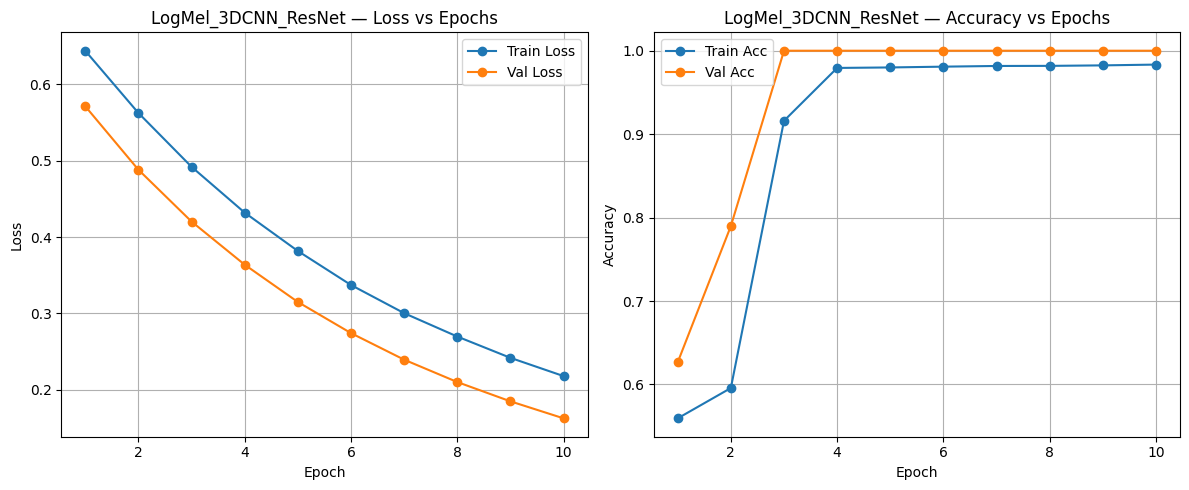


Evaluating LogMel_3DCNN_ResNet on Test Set...



Final Test Accuracy: 0.9697
Latency: 2.84 ms | FPS: 351.8


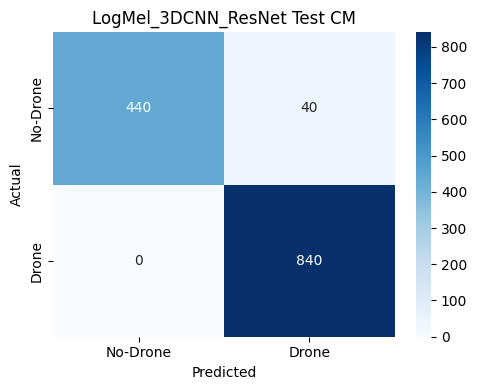

In [14]:

name = "LogMel_3DCNN_ResNet"
# ── 2. Build the Fusion Model ──────────────────────────────────────────────
fusion_model = LateFusionModel(
    model_audio=audio_bb,
    model_visual=visual_bb,
    model_rf=rf_bb
).to(DEVICE)

# التحقق من البارامترات القابلة للتدريب (يجب أن تكون فقط في الـ Fusion Head)
trainable_params = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"Total trainable parameters (Fusion Head): {trainable_params}")

# ── 3. Training Configuration ──────────────────────────────────────────────
criterion = nn.BCELoss()
# التدريب فقط لطبقة الـ final_pred
optimizer = optim.Adam(fusion_model.final_pred.parameters(), lr=LR)

# ── 4. Execution (Train & Evaluate) ────────────────────────────────────────
# التدريب
fusion_model, history = train_fusion(
    fusion_model, loaders, DEVICE, optimizer, criterion,
    num_epochs=NUM_EPOCHS
)

# عرض النتائج
plot_training_history(history, title_prefix=name)

# التقييم النهائي على التست
print(f"\nEvaluating {name} on Test Set...")
test_metrics = test_fusion(fusion_model, loaders['test'], DEVICE, dataset_name=f'{name} Test')

# طباعة التقرير النهائي
print(f"\nFinal Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Latency: {test_metrics['avg_ms']:.2f} ms | FPS: {test_metrics['fps']:.1f}")

plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], f'{name} Test CM')



Evaluating LogMel_3DCNN_ResNet on Training Set...


Final Train Accuracy: 0.9805


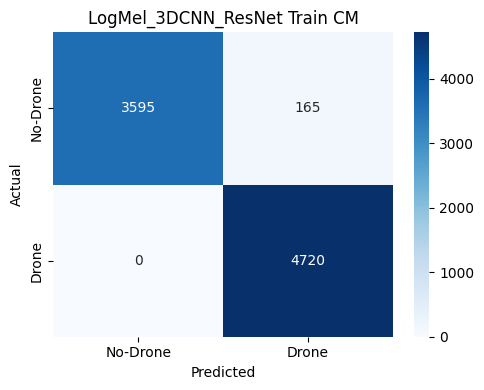

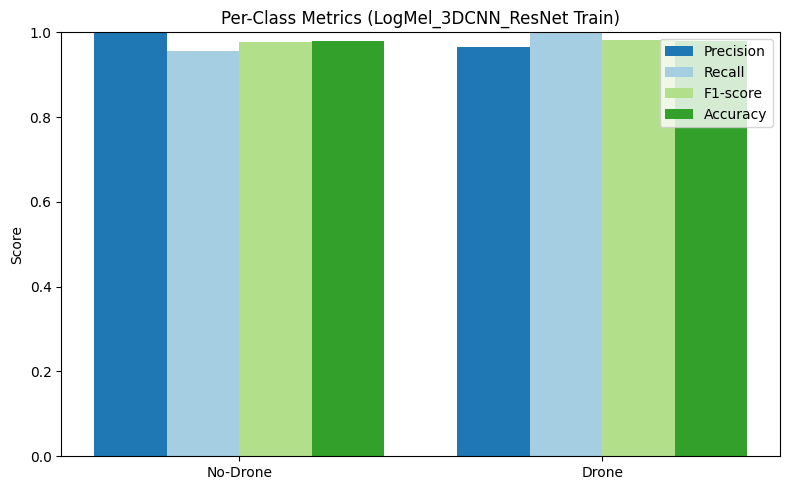


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     1.0000    0.9561    0.9776      3760
       Drone     0.9662    1.0000    0.9828      4720

    accuracy                         0.9805      8480
   macro avg     0.9831    0.9781    0.9802      8480
weighted avg     0.9812    0.9805    0.9805      8480



In [23]:
# --- (Training Set) ---
print(f"\nEvaluating {name} on Training Set...")
train_metrics = test_fusion(fusion_model, loaders['train'], DEVICE, dataset_name=f'{name} Train')
print(f"Final Train Accuracy: {train_metrics['accuracy']:.4f}")
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], f'{name} Train CM')
plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], dataset_name=f'{name} Train')
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], dataset_name='Train')



Evaluating LogMel_3DCNN_ResNet on Validation Set...


Final Val Accuracy: 1.0000


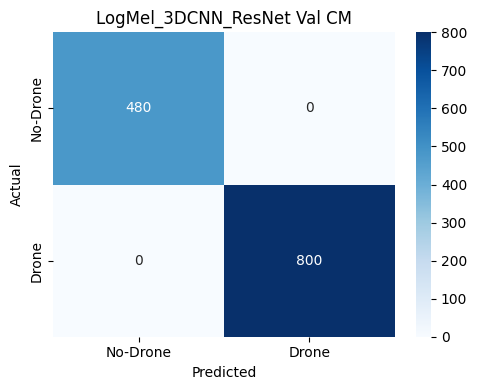

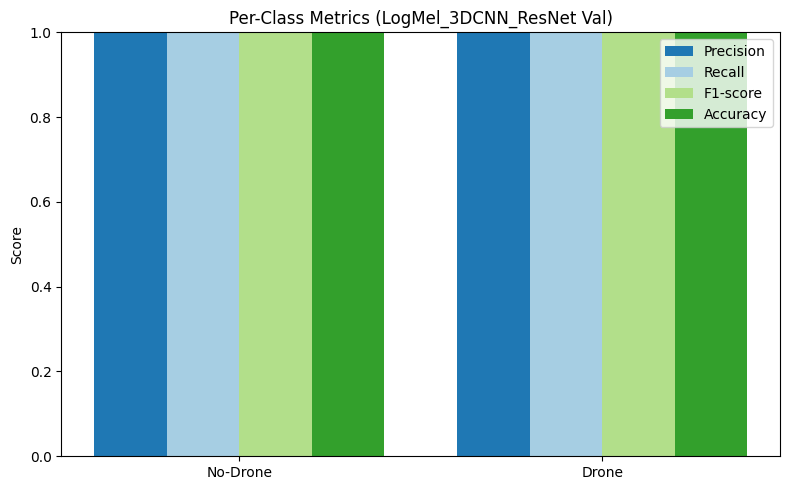


===== Val Classification Report =====
              precision    recall  f1-score   support

    No-Drone     1.0000    1.0000    1.0000       480
       Drone     1.0000    1.0000    1.0000       800

    accuracy                         1.0000      1280
   macro avg     1.0000    1.0000    1.0000      1280
weighted avg     1.0000    1.0000    1.0000      1280



In [15]:
# --(Validation Set) ---
print(f"\nEvaluating {name} on Validation Set...")
val_metrics = test_fusion(fusion_model, loaders['val'], DEVICE, dataset_name=f'{name} Val')
print(f"Final Val Accuracy: {val_metrics['accuracy']:.4f}")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], f'{name} Val CM')
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], dataset_name=f'{name} Val')
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], dataset_name='Val')


Evaluating LogMel_3DCNN_ResNet on Test Set...



Final Test Accuracy: 0.9697
Latency: 2.37 ms | FPS: 422.4


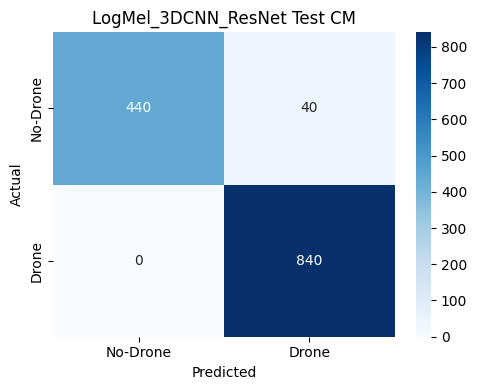

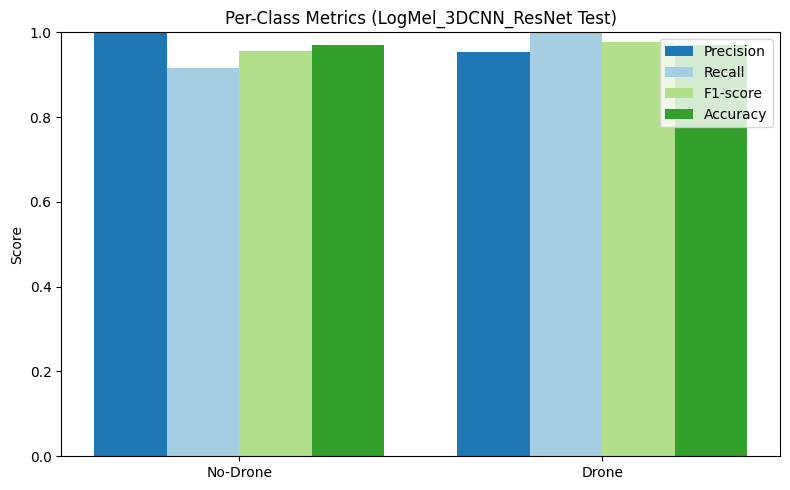


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     1.0000    0.9167    0.9565       480
       Drone     0.9545    1.0000    0.9767       840

    accuracy                         0.9697      1320
   macro avg     0.9773    0.9583    0.9666      1320
weighted avg     0.9711    0.9697    0.9694      1320



In [16]:
# ---ا(Test Set) ---
print(f"\nEvaluating {name} on Test Set...")
test_metrics = test_fusion(fusion_model, loaders['test'], DEVICE, dataset_name=f'{name} Test')
print(f"\nFinal Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Latency: {test_metrics['avg_ms']:.2f} ms | FPS: {test_metrics['fps']:.1f}")
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], f'{name} Test CM')
plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], dataset_name=f'{name} Test')
print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], dataset_name='Test')

In [21]:
import os
import torch
import pickle
from google.colab import files

def get_unique_path_local(name, ext):
    """
    """
    p = f'{name}{ext}'
    c = 1
    while os.path.exists(p):
        p = f'{name}_v{c}{ext}'
        c += 1
    return p

def save_combination_and_download(combo_name, model, history,
                                 train_metrics, val_metrics, test_metrics):
    """
    حفظ الأوزان (.pth) والنتائج (.pkl) ثم تحميلهما مباشرة إلى جهازك.
    """
    # 1. تحديد الأسماء الفريدة في المجلد الحالي (ليس Drive)
    w_path = get_unique_path_local(combo_name, '_weights.pth')
    r_path = get_unique_path_local(combo_name, '_results.pkl')

    # 2. حفظ أوزان النموذج
    torch.save(model.state_dict(), w_path)

    # 3. تجميع النتائج في قاموس وحفظه بتنسيق pickle
    results = {
        'combo_name':    combo_name,
        'history':       history,
        'train_metrics': train_metrics,
        'val_metrics':   val_metrics,
        'test_metrics':  test_metrics,
        'detection_time': {
            'avg_ms': test_metrics['avg_ms'],
            'fps':    test_metrics['fps'],
        }
    }

    with open(r_path, 'wb') as fh:
        pickle.dump(results, fh)

    print(f'Done saving: {w_path} and {r_path}')
    print('Starting download to your PC...')

    # 4. إرسال الملفات للمتصفح للتحميل
    # ملاحظة: قد يطلب المتصفح إذن "Allow multiple downloads"
    files.download(w_path)
    files.download(r_path)

    return w_path, r_path



In [24]:
save_combination_and_download(name, fusion_model, history, train_metrics, val_metrics, test_metrics)

Done saving: LogMel_3DCNN_ResNet_weights.pth and LogMel_3DCNN_ResNet_results.pkl
Starting download to your PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

('LogMel_3DCNN_ResNet_weights.pth', 'LogMel_3DCNN_ResNet_results.pkl')